# From Classical Time-Series Models to LLMs - Antarctic Sea Ice Extent
 
Seminar: Temporal Modeling </br>
Semester: WS2025(2026) </br>
Student: Leonie Schafferhans </br>

In [1]:
# all the imports
import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error

from openai import OpenAI

We investigated on data on the extension of sea ice in the Antarctic Region. The Data includes daily sea ice extent in [Million km²] starting from October 1978 up until January 21st 2026. </br></br>
_Fetterer, F., Knowles, K., Meier, W. N., Savoie, M., Windnagel, A. K. & Stafford, T. (2025). Sea Ice Index. (G02135, Version 4). [Data Set]. Boulder, Colorado USA. National Snow and Ice Data Center. https://doi.org/10.7265/a98x-0f50. Date Accessed 01-22-2026._

## 1. Data Loading
We will start by extracting, aggregating and visualising the data. It is important to note that we aggregate the data from daily measurements to monthly averaged measurements. This is for improving computational efficiency

In [2]:
# Load data
df = pd.read_csv("S_seaice_extent_daily_v4.csv")
df.columns = df.columns.str.strip() # Remove any leading/trailing whitespace from column names
df.drop(columns=["Source Data"], inplace=True) # Drop unnecessary column
df = df.groupby(['Year', 'Month'], as_index=False)['Extent'].mean() # Monthly average for computational efficiency
print(df.head())

   Year  Month     Extent
0  1978     10  17.699000
1  1978     11  15.896400
2  1978     12  10.395250
3  1979      1   5.402200
4  1979      2   3.141071


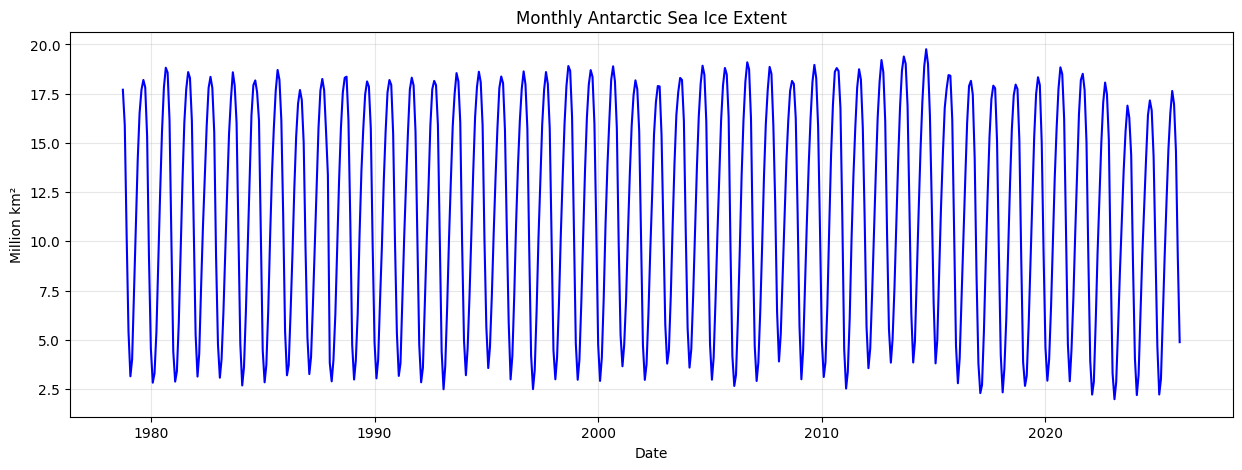

In [3]:
# Create datetime index
df["date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))
df.set_index("date", inplace=True)

# Keep only Extent
ice = df["Extent"]

# Plot
plt.figure(figsize=(15,5))
plt.plot(ice, color="blue")
plt.title("Monthly Antarctic Sea Ice Extent")
plt.ylabel("Million km²")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.show()


## 2. Data Exploration
We will see what are the underlying processes in the data. Is there a trend observable? Do we find Seasonality or Stationarity?
We assume, looking at the previous visualisation, there is a yearly seasonality. Which seems intuitive. We use a implemented _statsmodels_ method for this purpose. The particular one used is based on Moving average Models.

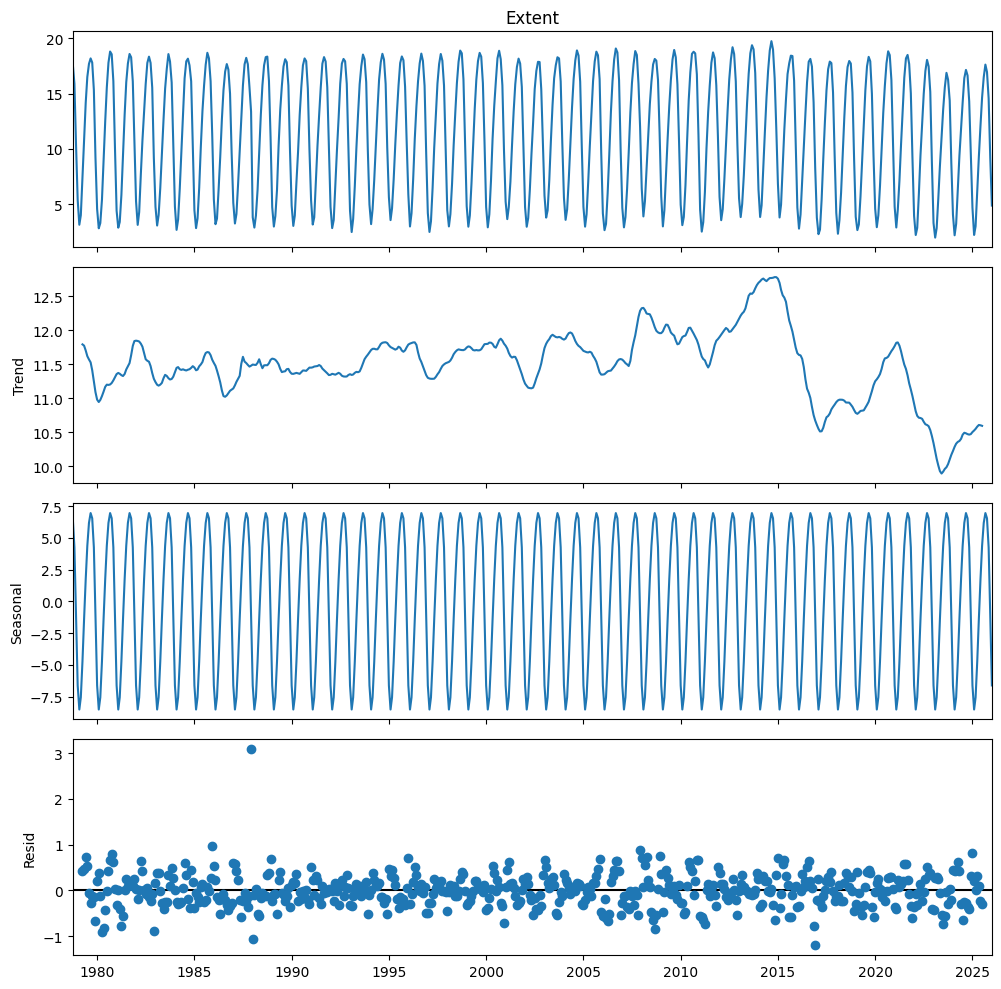

ADF Statistic: -3.349125637142821
p-value: 0.012820369278714423


In [70]:
# 1. Decomposition (Assuming monthly data, period=12) and plot
result = seasonal_decompose(df['Extent'], model='additive', period=12) 
result.plot()
plt.show()

# Stationarity Test (Augmented Dickey-Fuller)
stats = adfuller(df['Extent'])
print(f'ADF Statistic: {stats[0]}')
print(f'p-value: {stats[1]}') # If p > 0.05, it is NOT stationary

For the trend we observe a declining trend starting around year 2015.

The Test for Stationarity reveals a p-value of < 0.5 (being 0.012820). This indicates that the data is has no unit root and can be considered statistically stationary and has a quite stable mean and variance over the time. That means, there is no need for differencing the data further.

## 3. SARIMA
First we will use a seasonal ARIMA model to fit the data and see how it predicts the Ice Extent.

In [4]:
# Train-test split (10 Months)
TEST_MONTHS = 10

train = ice.iloc[:-TEST_MONTHS]
test = ice.iloc[-TEST_MONTHS:]

print("Train end:", train.index[-1])
print("Test start:", test.index[0])

Train end: 2025-03-01 00:00:00
Test start: 2025-04-01 00:00:00


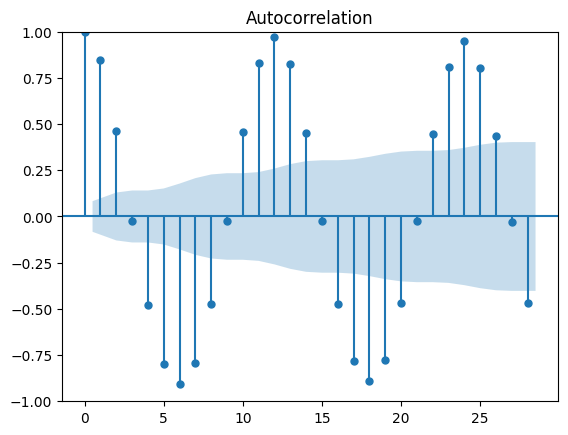

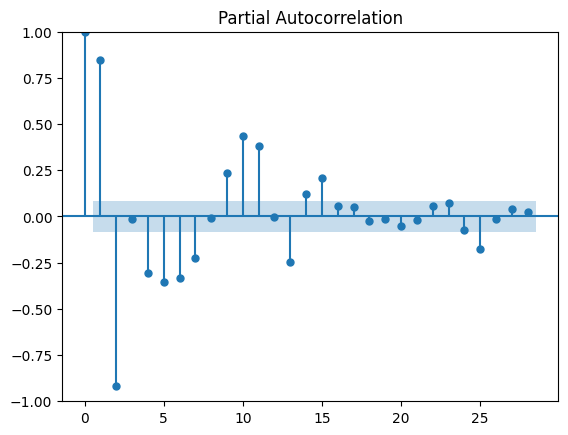

In [5]:
plot_acf(train)
plot_pacf(train)
plt.show()

In [6]:
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12)) # p,d,q (P,D,Q,s)
model_fit = model.fit()
print(model_fit.summary())

c:\Users\Leonie\miniconda3\envs\ch1\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Leonie\miniconda3\envs\ch1\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                             Extent   No. Observations:                  558
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -279.948
Date:                            Tue, 17 Feb 2026   AIC                            569.895
Time:                                    19:45:19   BIC                            591.399
Sample:                                10-01-1978   HQIC                           578.302
                                     - 03-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6055      0.035     17.088      0.000       0.536       0.675
ma.L1         -0.9118      0.028   

In [7]:
steps = len(test)

fc = model_fit.get_forecast(steps=steps) # get forecast
forecast_values = fc.predicted_mean 

# Force correct datetime index for better plotting
forecast_index = pd.date_range(
    start=train.index[-1] + pd.Timedelta(days=1),
    periods=steps,
    freq="M"
)
pred = pd.Series(
    forecast_values.values,
    index=forecast_index,
    name="Forecast"
)

# Sanity check  - looks good :)
print("\nForecast index:")
print(pred.index)


Forecast index:
DatetimeIndex(['2025-03-31', '2025-04-30', '2025-05-31', '2025-06-30',
               '2025-07-31', '2025-08-31', '2025-09-30', '2025-10-31',
               '2025-11-30', '2025-12-31'],
              dtype='datetime64[ns]', freq='ME')


C:\Users\Leonie\AppData\Local\Temp\ipykernel_23708\2230848081.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(


In [8]:
# combine actual and forecast for comparison
actual_full = pd.concat([train, test])
forecast_full = pd.concat([train, pred])

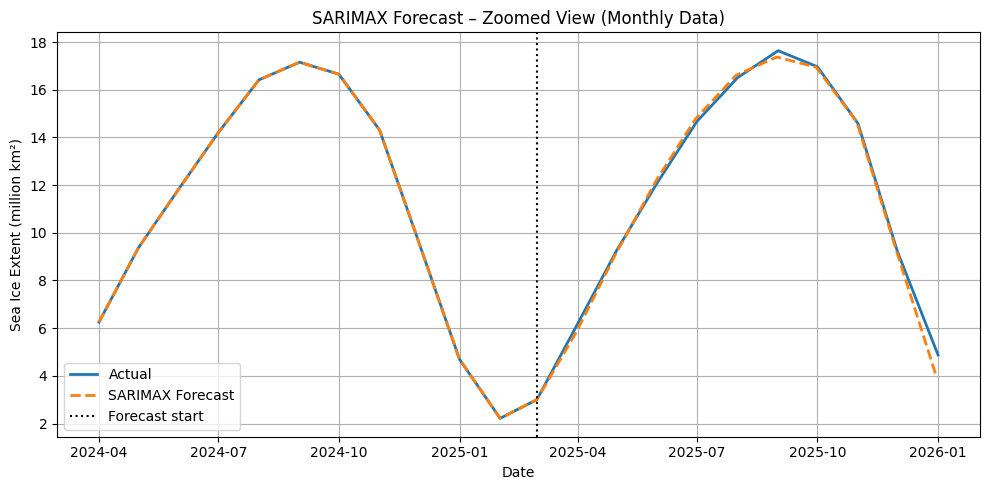

In [9]:
ZOOM_MONTHS = 12 # last 12 months zoom window for better visibility
zoom_start = train.index[-ZOOM_MONTHS]

plt.figure(figsize=(10,5))

plt.plot(
    actual_full.loc[zoom_start:],
    label="Actual",
    linewidth=2
)

plt.plot(
    forecast_full.loc[zoom_start:],
    "--",
    label="SARIMAX Forecast",
    linewidth=2
)

plt.axvline(
    train.index[-1],
    color="black",
    linestyle=":",
    label="Forecast start"
)

plt.title("SARIMAX Forecast – Zoomed View (Monthly Data)")
plt.ylabel("Sea Ice Extent (million km²)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

We will compute the Mean Absolute Error (MAE) and Mean Squared Error (MSE) to get a quantified error measurement in addition to the visualization.

In [10]:
observed = df['Extent'].tail(TEST_MONTHS)

mae = mean_absolute_error(observed, forecast_full.tail(TEST_MONTHS))
mse = mean_squared_error(observed, forecast_full.tail(TEST_MONTHS))

print("MAE:", mae)
print("MSE:", mse)

MAE: 0.2194086344385393
MSE: 0.1166031937692928


## 4. Markov Chains 

We implemented a Markov Chain Model. The states are defined as "Growing Ice", "Declining Ice" and "Stable Ice" respective to the change to the previous timestep.

In [6]:
# define states based on change in ice extent
def ice_trend(delta):
    if delta > 0:
        return "Growing ice"
    elif delta < 0:
        return "Declining ice"
    else:
        return "Stable ice"

train_states = train.diff().apply(ice_trend)
test_states = test.diff().apply(ice_trend)

In [7]:
# Transition probabilities
transitions = pd.DataFrame({
    "from": train_states[:-1].values,
    "to": train_states[1:].values
})
transition_counts = pd.crosstab(
    transitions["from"],
    transitions["to"]
)
transition_matrix = transition_counts.div(
    transition_counts.sum(axis=1),
    axis=0
)

print("Markov Transition Matrix:")
print(transition_matrix)



Markov Transition Matrix:
to             Declining ice  Growing ice
from                                     
Declining ice       0.798283     0.201717
Growing ice         0.142415     0.857585
Stable ice          1.000000     0.000000


In [8]:
predicted_states = []
current_state = train_states.iloc[-1]

for _ in range(10):
    probs = transition_matrix.loc[current_state].values
    next_state = np.random.choice(transition_matrix.columns, p=probs)
    predicted_states.append(next_state)
    current_state = next_state

print("Predicted next 10 states:")
print(predicted_states)
print("\nActual next 10 states:")
print(test_states.values[:10])

Predicted next 10 states:
['Growing ice', 'Growing ice', 'Growing ice', 'Growing ice', 'Growing ice', 'Growing ice', 'Growing ice', 'Declining ice', 'Growing ice', 'Growing ice']

Actual next 10 states:
['Stable ice' 'Growing ice' 'Growing ice' 'Growing ice' 'Growing ice'
 'Growing ice' 'Declining ice' 'Declining ice' 'Declining ice'
 'Declining ice']


In [9]:
pred = np.array(predicted_states)
true = np.array(test_states)

error = np.mean(pred != true)

print(f"Error rate: {error:.3f}")
print(f"Accuracy: {1 - error:.3f}")

Error rate: 0.400
Accuracy: 0.600


## 5. Finetuning OpenAI *gpt-3.5-turbo*

Since State Space Models do not provide meaningful insights, we additionally exploited the possibilities of fine-tuning LLMs. 
For the final task we fine-tune a pretrained OpenAI GPT model to predict the Sea Ice Extent for the next few months. 
We do this by utilizing fine-tuning services provided by OpenAI.

In [148]:
# read data (again for clarity)
df = pd.read_csv("S_seaice_extent_daily_v4.csv")
df.columns = df.columns.str.strip()
df.drop(columns=["Source Data"], inplace=True)
df = df.groupby(['Year', 'Month'], as_index=False)['Extent'].mean()
df["date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))
df.set_index("date", inplace=True)
df.head()
ice = df["Extent"] # Keep only Extent

In [149]:
# Train-test split (10 Months)
TEST_MONTHS = 10

train = ice.iloc[:-TEST_MONTHS]
test = ice.iloc[-TEST_MONTHS:]

print("Train end:", train.index[-1])
print("Test start:", test.index[0])

Train end: 2025-03-01 00:00:00
Test start: 2025-04-01 00:00:00


In [150]:
#  normalize data to [0,1] better for modelling
min_val = train.min()
max_val = train.max()

ice_norm = (ice - min_val) / (max_val - min_val) # min-max normalization

In [100]:
# convert to sequences for training - use last 36 months to predict next 12 months
input_window = 36
output_window = 12

sequences = []
for start in range(len(ice_norm) - input_window - output_window + 1):
    input_seq = ice_norm[start:start+input_window].values
    output_seq = ice_norm[start+input_window:start+input_window+output_window].values
    sequences.append((input_seq, output_seq))

In [101]:
# create training JSONL file for fine-tuning matching the Chat API format
output_file = "new_ice_train.jsonl"

# system prompt
system_message = "Predict the next 12 months of data based on the provided sequence."

with open(output_file, "w") as f_out:
    for input_seq, output_seq in sequences:
        # Convert sequences to comma-separated strings
        prompt_str = ",".join(map(str, input_seq)) + " =>"
        completion_str = " " + ",".join(map(str, output_seq)) + " "
        
        # Structure it for the Chat API
        new_entry = {
            "messages": [
                {"role": "system", "content": system_message},
                {"role": "user", "content": prompt_str},
                {"role": "assistant", "content": completion_str}
            ]
        }
        
        # Save each entry as a single line JSON
        f_out.write(json.dumps(new_entry) + "\n")


In [ ]:
# Initialize client
# api key redacted for security
client = OpenAI(api_key="XXXX")


In [103]:
# upload training JSONL file for fine-tuning and get file ID (need this for later)
upload_response = client.files.create(
    file=open("new_ice_train.jsonl", "rb"),
    purpose="fine-tune"
)
file_id = upload_response.id
print("Uploaded file ID:", file_id)

Uploaded file ID: file-579YxaeZS63K7BrChUqxFe


In [104]:
# start fine-tuning job on gpt-3.5-turbo
response = client.fine_tuning.jobs.create(
    training_file = 'file-8zYXVi9gD6hWftk49aX9DY',
  model="gpt-3.5-turbo"
)
print(response)

FineTuningJob(id='ftjob-ToWgnAT27wp5D9mSIAQdqRqO', created_at=1769693712, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs='auto'), model='gpt-3.5-turbo-0125', object='fine_tuning.job', organization_id='org-8zzfdBqpv6rDyiPkz52QrtVA', result_files=[], seed=1368567113, status='validating_files', trained_tokens=None, training_file='file-8zYXVi9gD6hWftk49aX9DY', validation_file=None, estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs='auto'))), user_provided_suffix=None, usage_metrics=None, shared_with_openai=False, eval_id=None)


In [154]:
# get history (train) for prediction input
last_36_values = train.tail(36).astype(str).tolist()
input_string = ", ".join(last_36_values)

print(f"Input string for prediction: {input_string}")

Input string for prediction: 5.948133333333334, 9.418129032258063, 12.2181, 14.986129032258065, 17.050225806451614, 18.062133333333335, 17.47358064516129, 15.1594, 8.838935483870968, 3.2964516129032257, 1.9776428571428573, 2.838225806451613, 5.537766666666667, 8.447354838709677, 11.114933333333333, 13.566096774193548, 15.574677419354838, 16.8906, 16.278258064516127, 14.378433333333334, 8.764935483870968, 4.04658064516129, 2.187310344827586, 3.2206451612903226, 6.252533333333333, 9.362677419354839, 11.8484, 14.201064516129032, 16.41409677419355, 17.15396666666667, 16.650129032258064, 14.312000000000001, 9.59309677419355, 4.6924838709677426, 2.2175000000000002, 3.0020645161290322


In [ ]:
# prompt for prediction 
full_prompt = f"{input_string}\nPredict the next 12 months:"

# call fine-tuned model and give prediction
response = client.chat.completions.create(
  model="XXXX",  # model id from fine-tuning step (redacted for security)
  messages=[
    {"role": "system", "content": "Predict the next 12 months of data based on the provided sequence."},
    {"role": "user", "content": full_prompt}
  ],
  temperature=0
)

print("Prediction:", response.choices[0].message.content)

Prediction: 5.946133333333334, 9.141612903225807, 11.7659, 14.051354838709677, 16.237733333333335, 17.541354838709678, 17.0481, 14.839354838709678, 10.282633333333334, 4.786774193548387, 1.661241935483871, 2.895548387096774


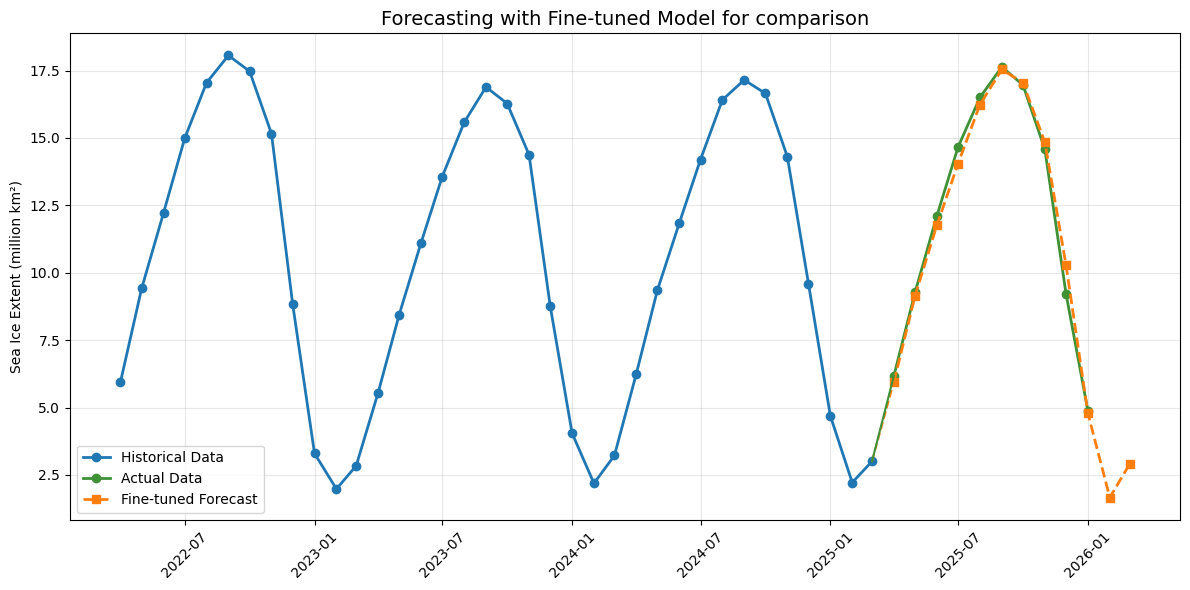

In [156]:
# plot results
# last 36 months history
history = train.tail(36).tolist()
history_dates = train.tail(36).index
history_values = train.tail(36).values

actual_dates = test.index
actual_values = test.values

# convert to datetime for plotting
last_date = history_dates[-1]
prediction_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), 
                                 periods=12, 
                                 freq='MS')
# predicted values (from the API response in the previous step)
predicted_values = [float(x) for x in response.choices[0].message.content.split(",")]

# create plotting indices 
history_idx = list(range(len(history)))
predict_idx = list(range(len(history), len(history) + len(predicted_values)))

plt.figure(figsize=(12, 6))

plt.plot(history_dates, history_values, label='Historical Data', 
         color='#1f77b4', marker='o', linewidth=2)

plt.plot(actual_dates, actual_values, label='Actual Data', 
         color="#3f9136", marker='o', linewidth=2)

plt.plot(prediction_dates, predicted_values, label='Fine-tuned Forecast', 
         color='#ff7f0e', linestyle='--', marker='s', linewidth=2)

# additional connection for continuity
plt.plot([history_dates[-1], prediction_dates[0]], 
         [history_values[-1], predicted_values[0]], 
         color='#ff7f0e', linestyle='--')

plt.plot([history_dates[-1], actual_dates[0]], 
         [history_values[-1], actual_values[0]], 
         color='#3f9136')

plt.title('Forecasting with Fine-tuned Model for comparison', fontsize=14)
plt.ylabel('Sea Ice Extent (million km²)')
plt.grid(True, alpha=0.3)
plt.legend()

# Rotate dates for better readability
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [157]:
print("Actual values:", actual_values)
print("Predicted values:", predicted_values[:10])

mae = mean_absolute_error(actual_values, predicted_values[:10])
mse = mean_squared_error(actual_values, predicted_values[:10])

print("MAE:", mae)
print("MSE:", mse)

Actual values: [ 6.17326667  9.27312903 12.1139     14.66490323 16.50206452 17.6363
 16.96470968 14.57613333  9.21829032  4.876     ]
Predicted values: [5.946133333333334, 9.141612903225807, 11.7659, 14.051354838709678, 16.237733333333335, 17.54135483870968, 17.0481, 14.839354838709678, 10.282633333333335, 4.786774193548387]
MAE: 0.31796548387096746
MSE: 0.1862344020334145


**Try predicting further**

In [158]:
# read data (again for clarity)
df = pd.read_csv("S_seaice_extent_daily_v4.csv")
df.columns = df.columns.str.strip()
df.drop(columns=["Source Data"], inplace=True)
df = df.groupby(['Year', 'Month'], as_index=False)['Extent'].mean()
df["date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))
df.set_index("date", inplace=True)
df.head()
ice = df["Extent"] # Keep only Extent

# get history (train) for prediction input
last_10_values = ice.tail(36).astype(str).tolist()
input_string = ", ".join(last_10_values)

print(f"Input string for prediction: {input_string}")

Input string for prediction: 1.9776428571428573, 2.838225806451613, 5.537766666666667, 8.447354838709677, 11.114933333333333, 13.566096774193548, 15.574677419354838, 16.8906, 16.278258064516127, 14.378433333333334, 8.764935483870968, 4.04658064516129, 2.187310344827586, 3.2206451612903226, 6.252533333333333, 9.362677419354839, 11.8484, 14.201064516129032, 16.41409677419355, 17.15396666666667, 16.650129032258064, 14.312000000000001, 9.59309677419355, 4.6924838709677426, 2.2175000000000002, 3.0020645161290322, 6.173266666666667, 9.273129032258064, 12.1139, 14.664903225806452, 16.502064516129032, 17.6363, 16.964709677419354, 14.576133333333333, 9.218290322580645, 4.876


In [ ]:
# prompt for prediction 
full_prompt = f"{input_string}\nPredict the next 12 months:"

# call fine-tuned model and give prediction
response = client.chat.completions.create(
  model="XXXX",  # model id from fine-tuning step (redacted for security)
  messages=[
    {"role": "system", "content": "Predict the next 12 months of data based on the provided sequence."},
    {"role": "user", "content": full_prompt}
  ],
  temperature=0
)

print("Prediction:", response.choices[0].message.content)

Prediction: 2.274741935483871, 3.2744, 6.470903225806452, 9.354709677419354, 11.909833333333334, 14.274774193548387, 16.370774193548386, 17.274633333333334, 16.47890322580645, 14.741741935483871, 9.519548387096775, 4.733


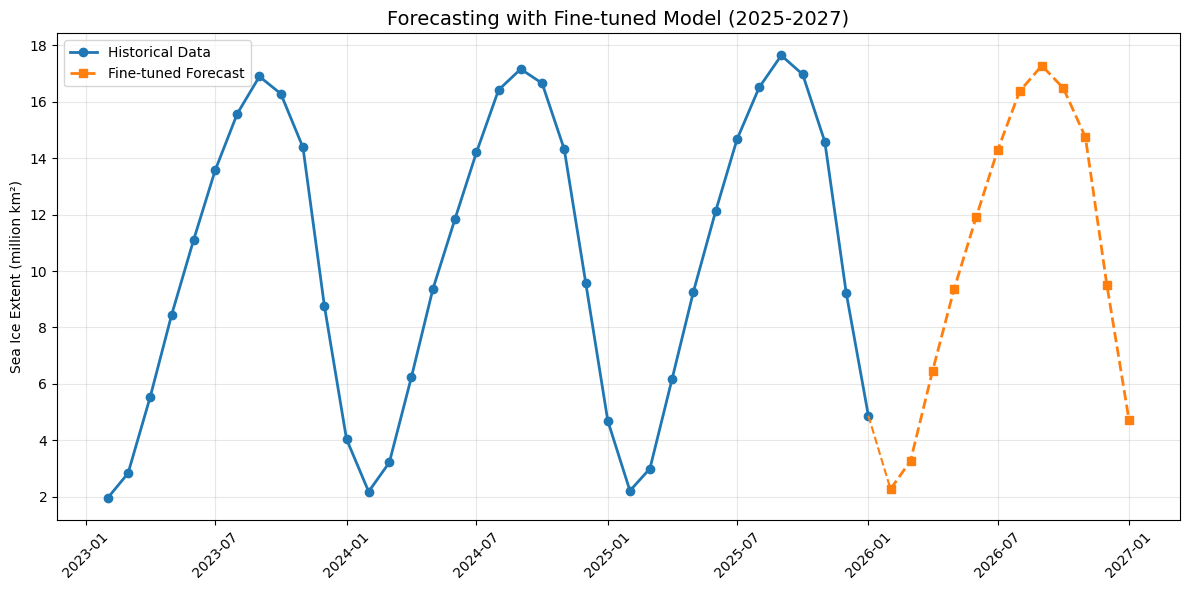

In [160]:
# plot results
# last 36 months history
history = ice.tail(36).tolist()
history_dates = ice.tail(36).index
history_values = ice.tail(36).values


# convert to datetime for plotting
last_date = history_dates[-1]
prediction_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), 
                                 periods=12, 
                                 freq='MS')
# predicted values (from the API response in the previous step)
predicted_values = [float(x) for x in response.choices[0].message.content.split(",")]

# create plotting indices 
history_idx = list(range(len(history)))
predict_idx = list(range(len(history), len(history) + len(predicted_values)))

plt.figure(figsize=(12, 6))

plt.plot(history_dates, history_values, label='Historical Data', 
         color='#1f77b4', marker='o', linewidth=2)

plt.plot(prediction_dates, predicted_values, label='Fine-tuned Forecast', 
         color='#ff7f0e', linestyle='--', marker='s', linewidth=2)

# additional connection for continuity
plt.plot([history_dates[-1], prediction_dates[0]], 
         [history_values[-1], predicted_values[0]], 
         color='#ff7f0e', linestyle='--')


plt.title('Forecasting with Fine-tuned Model (2025-2027)', fontsize=14)
plt.ylabel('Sea Ice Extent (million km²)')
plt.grid(True, alpha=0.3)
plt.legend()

# Rotate dates for better readability
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()